# Model Analysis

This notebook covers Tasks 2–4 and Bonus A/B: regression model training, feature selection, hyperparameter tuning, final evaluation, and sex classification from DNA methylation data.

Data loading and splitting mirrors `data_exploration.ipynb` (80/20 stratified split, seed=42). All preprocessing is fit exclusively on the training split.

In [3]:
import sys
import os
import importlib
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, uniform

sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

import functions
importlib.reload(functions)
from functions import (
    load_data, split_data, create_age_bins,
    get_feature_names, create_preprocessor, train_and_evaluate_model,
    stability_selection, parse_results_table,
    plot_bootstrap_boxplots, plot_stability_selection,
    select_mrmr_K, select_mrmr_features,
    plot_mrmr_K_curve, plot_feature_set_overlap,
    tune_model, plot_tuning_cv_results,
    bootstrap_evaluate,
    plot_all_metrics_boxplots, plot_pred_vs_actual,
    optuna_tune_model, plot_optuna_history,
    select_sex_mrmr, bootstrap_classify,
    plot_sex_cpg_bar, plot_confusion_matrices,
    plot_roc_curves, plot_classification_boxplots,
)

# --- Load and split data (strict protocol mirrored from data_exploration.ipynb) ---
dev_data_path  = '../data/development_data.csv'
eval_data_path = '../data/evaluation_data.csv'

dev_df   = load_data(dev_data_path)
eval_df  = load_data(eval_data_path)

dev_df = create_age_bins(dev_df)
train_df_full, val_df_full = split_data(
    dev_df,
    test_size=0.2,
    stratify_by='age_bin',
    random_state=42
)

# Apply preprocessing decisions from Task 1.2 directly (no re-testing in this notebook).
train_df = train_df_full.copy()
val_df = val_df_full.copy()
if 'sex' in train_df.columns:
    train_df = train_df.drop(columns=['sex'])
    val_df = val_df.drop(columns=['sex'])

cpg_features, _ = get_feature_names(train_df)
categorical_features = ['ethnicity'] if 'ethnicity' in train_df.columns else []

print("Using fixed preprocessing decisions from Task 1.2 (no ANOVA rerun):")
print("  - sex excluded")
print(f"  - categorical retained: {categorical_features}")
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Eval: {len(eval_df)}")
print(f"CpG features: {len(cpg_features)}  Categorical features: {categorical_features}")

Using fixed preprocessing decisions from Task 1.2 (no ANOVA rerun):
  - sex excluded
  - categorical retained: ['ethnicity']
Train: 364  Val: 92  Eval: 100
CpG features: 1000  Categorical features: ['ethnicity']


## Task 2.1: OLS Linear Regression Baselines

In [4]:
# --- Task 2.1: OLS Linear Regression across feature sets ---
# Feature sets from Task 1.2d:
#   (A) CpG only       — 1000 probes
#   (B) CpG + ethnicity — 1001 columns (ethnicity one-hot encoded, 2 indicators)
# sex is excluded (ANOVA non-significant). No CV or tuning applied.

feature_sets_21 = {
    "OLS – CpG only":        (cpg_features,                      []),
    "OLS – CpG + ethnicity": (cpg_features, categorical_features),   # ['ethnicity']
}

ols_results_21 = {}
ols_raw_21     = {}

for name, (cpg_cols, cat_cols) in feature_sets_21.items():
    feature_cols_21 = cpg_cols + cat_cols
    preprocessor_21 = create_preprocessor(cpg_cols, cat_cols)
    print(f"Training {name}  ({len(feature_cols_21)} features) ...")
    summary, raw = train_and_evaluate_model(
        train_df, val_df,
        feature_cols=feature_cols_21,
        target_col='age',
        preprocessor=preprocessor_21,
        n_bootstraps=1000,
        seed=42,
        model=None,          # LinearRegression (OLS)
        return_raw=True,
    )
    ols_results_21[name] = summary
    ols_raw_21[name]     = raw
    print(f"  RMSE:    {summary['rmse']}")
    print(f"  MAE:     {summary['mae']}")
    print(f"  R²:      {summary['r2']}")
    print(f"  Pearson: {summary['pearsonr']}")
    print()

print("Table 2.1 — OLS baseline results (1000 bootstrap resamples on validation set)")
display(parse_results_table(ols_results_21))

Training OLS – CpG only  (1000 features) ...
  RMSE:    4.911 (95% CI: 4.355-5.458)
  MAE:     4.162 (95% CI: 3.644-4.694)
  R²:      0.885 (95% CI: 0.842-0.920)
  Pearson: 0.946 (95% CI: 0.923-0.963)

Training OLS – CpG + ethnicity  (1001 features) ...
  RMSE:    4.910 (95% CI: 4.359-5.457)
  MAE:     4.156 (95% CI: 3.632-4.686)
  R²:      0.885 (95% CI: 0.843-0.920)
  Pearson: 0.946 (95% CI: 0.923-0.963)

Table 2.1 — OLS baseline results (1000 bootstrap resamples on validation set)


,RMSE Mean,RMSE 95% CI,MAE Mean,MAE 95% CI,R²,R² 95% CI,Pearson r,Pearson r 95% CI
Model,,,,,,,,
OLS – CpG only,4.911,4.355-5.458,4.162,3.644-4.694,0.885,0.842-0.920,0.946,0.923-0.963
OLS – CpG + ethnicity,4.910,4.359-5.457,4.156,3.632-4.686,0.885,0.843-0.920,0.946,0.923-0.963


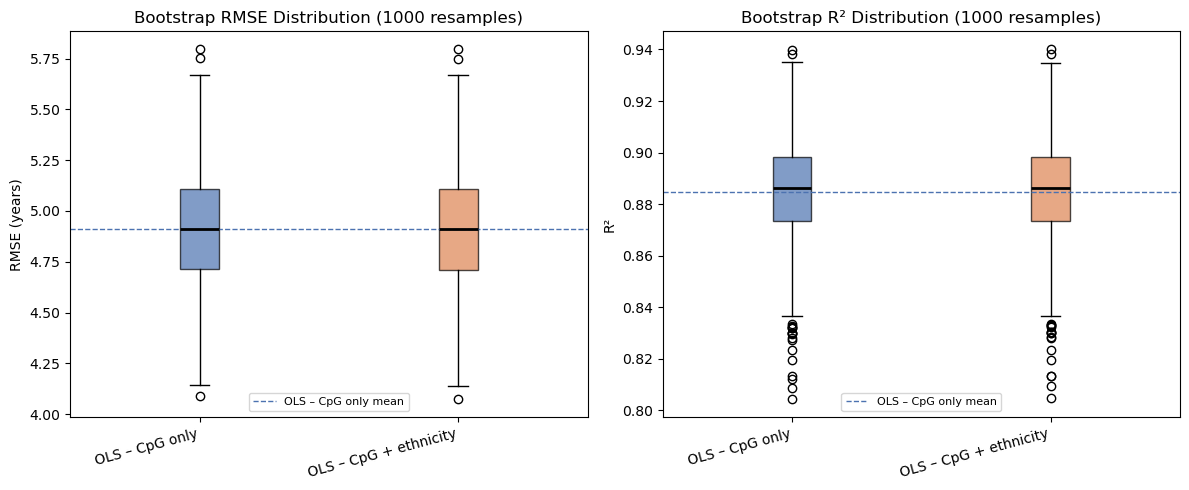

In [5]:
plot_bootstrap_boxplots(
    ols_raw_21,
    baseline_key="OLS – CpG only",
    save_path="../figures/task2_1_bootstrap_boxplots.png"
)

Does ethnicity improve the OLS baseline?

**OLS – CpG only** is the primary baseline: it isolates the predictive signal of the 1000 methylation probes alone, with no demographic confound.

**OLS – CpG + ethnicity** adds a one-hot encoded ethnicity indicator. Under strict protocol, categorical inclusion is decided from **training-split ANOVA only**: sex is excluded (non-significant at α=0.05), while ethnicity is retained (significant at α=0.05). Adding this cohort indicator can shift predictions toward the correct cohort mean, potentially reducing RMSE.

Both models are trained once on the 364-sample training set with no regularisation or cross-validation. Bootstrap resampling (1000 resamples, seed = 42) is applied exclusively to the held-out validation predictions to obtain 95% percentile CIs on RMSE, MAE, R², and Pearson r.

## Task 2.2: Three Regression Models at Default Hyperparameters

Train ElasticNet, SVR (RBF kernel), and BayesianRidge on the CpG-only feature set (1000 features) and compare against the OLS baseline using the same bootstrap protocol (1000 resamples, 95% CI).

In [6]:
cpg_features, categorical_features = get_feature_names(train_df)

models_2_2 = {
    "OLS (baseline)": None,
    "ElasticNet": ElasticNet(),
    "SVR (RBF)": SVR(),
    "BayesianRidge": BayesianRidge(),
}

task2_results = {}
task2_raw = {}

for name, model in models_2_2.items():
    print(f"Training {name} ...")
    summary, raw = train_and_evaluate_model(
        train_df, val_df,
        feature_cols=cpg_features, target_col='age',
        preprocessor=create_preprocessor(cpg_features, []),
        n_bootstraps=1000, seed=42,
        model=model, return_raw=True
    )
    task2_results[name] = summary
    task2_raw[name] = raw
    for metric, value in summary.items():
        print(f"  {metric.upper()}: {value}")
    print()


Training OLS (baseline) ...
  RMSE: 4.911 (95% CI: 4.355-5.458)
  MAE: 4.162 (95% CI: 3.644-4.694)
  R2: 0.885 (95% CI: 0.842-0.920)
  PEARSONR: 0.946 (95% CI: 0.923-0.963)

Training ElasticNet ...
  RMSE: 4.331 (95% CI: 3.762-4.874)
  MAE: 3.547 (95% CI: 2.999-4.077)
  R2: 0.911 (95% CI: 0.880-0.936)
  PEARSONR: 0.959 (95% CI: 0.942-0.972)

Training SVR (RBF) ...
  RMSE: 9.089 (95% CI: 7.377-11.129)
  MAE: 6.908 (95% CI: 5.781-8.136)
  R2: 0.612 (95% CI: 0.528-0.691)
  PEARSONR: 0.848 (95% CI: 0.791-0.895)

Training BayesianRidge ...
  RMSE: 4.353 (95% CI: 3.808-4.876)
  MAE: 3.645 (95% CI: 3.174-4.132)
  R2: 0.910 (95% CI: 0.876-0.937)
  PEARSONR: 0.956 (95% CI: 0.938-0.970)



In [7]:
display(parse_results_table(task2_results))


,RMSE Mean,RMSE 95% CI,MAE Mean,MAE 95% CI,R²,R² 95% CI,Pearson r,Pearson r 95% CI
Model,,,,,,,,
OLS (baseline),4.911,4.355-5.458,4.162,3.644-4.694,0.885,0.842-0.920,0.946,0.923-0.963
ElasticNet,4.331,3.762-4.874,3.547,2.999-4.077,0.911,0.880-0.936,0.959,0.942-0.972
SVR (RBF),9.089,7.377-11.129,6.908,5.781-8.136,0.612,0.528-0.691,0.848,0.791-0.895
BayesianRidge,4.353,3.808-4.876,3.645,3.174-4.132,0.910,0.876-0.937,0.956,0.938-0.970


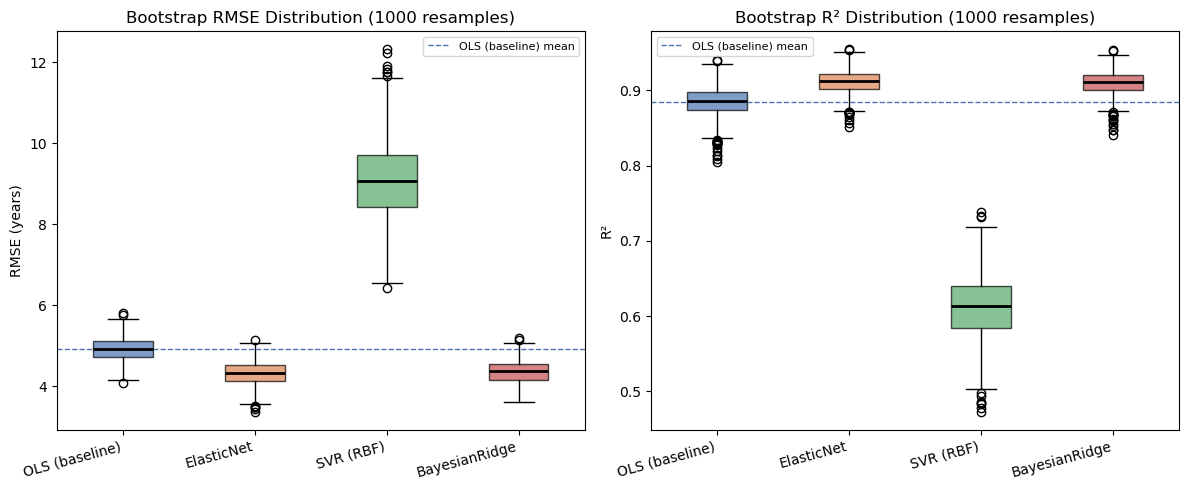

In [8]:
plot_bootstrap_boxplots(
    task2_raw,
    baseline_key="OLS (baseline)",
    save_path="../figures/task2_2_bootstrap_boxplots.png"
)


All models are trained on the 364-sample training set using CpG-only features (1000 probes). Bootstrap resampling (1000 resamples, seed = 42) is applied to held-out validation predictions; 95% CIs are percentile intervals.

| Model | RMSE (95% CI) | MAE (95% CI) | R² (95% CI) | Pearson r (95% CI) | Beats OLS? |
|---|---|---|---|---|---|
| OLS (baseline) | 4.911 (4.355–5.458) | 4.162 (3.644–4.694) | 0.885 (0.842–0.920) | 0.946 (0.923–0.963) | — |
| ElasticNet | 4.331 (3.762–4.874) | 3.547 (2.999–4.077) | 0.911 (0.880–0.936) | 0.959 (0.942–0.972) | Yes (−11.8% RMSE) |
| SVR (RBF) | 9.089 (7.377–11.129) | 6.908 (5.781–8.136) | 0.612 (0.528–0.691) | 0.848 (0.791–0.895) | No (+85.1% RMSE) |
| BayesianRidge | 4.353 (3.808–4.876) | 3.645 (3.174–4.132) | 0.910 (0.876–0.937) | 0.956 (0.938–0.970) | Yes (−11.4% RMSE) |

**ElasticNet** beats OLS by 11.8 % in RMSE. With 1000 features and only 364 training samples the problem is heavily underdetermined (p ≫ n), so OLS overfits the training noise. ElasticNet's combined L1+L2 penalty shrinks small coefficients to zero, performing implicit feature selection. The confidence intervals do not overlap with OLS, confirming a robust gain.

**SVR (RBF)** is far worse than OLS — RMSE 9.089 vs 4.911, an 85 % increase. At default hyperparameters (`C=1`, `epsilon=0.1`, `gamma='scale'`), the RBF kernel bandwidth becomes very narrow in a 1000-dimensional space, making each training sample nearly isolated. The model cannot generalise and predictions collapse toward the global mean. **SVR does not justify inclusion at default settings.**

**BayesianRidge** beats OLS by 11.4 % in RMSE. It estimates the regularisation strength from the data via evidence maximisation, effectively applying an adaptive ridge penalty. The result is nearly identical to ElasticNet, confirming that any form of shrinkage is the key gain over plain OLS in this p ≫ n regime.

**Conclusion:** ElasticNet and BayesianRidge both beat the OLS floor and proceed to Tasks 3 and 4. SVR fails at default settings but is included in Task 4.1 to test whether tuning recovers competitive performance.

## Task 3: Feature Selection

Reducing the 1000 CpG features to a smaller, more informative subset can improve generalisation by removing noisy or redundant probes.

### Task 3.1: Stability Selection

Stability selection estimates feature robustness across data perturbations:
1. Draw 50 subsamples (80 % of training data, **without** replacement).
2. Per subsample, rank CpG features by |Spearman ρ| with age; keep top 200.
3. A feature is **stable** if it appears in **> 25** of the 50 resamples (> 50 %).

In [9]:
cpg_features, _ = get_feature_names(train_df)

stable_features, selection_counts = stability_selection(
    train_df,
    cpg_features=cpg_features,
    target_col='age',
    n_subsamples=50,
    subsample_frac=0.8,
    top_k=200,
    threshold=0.5,
    seed=42
)

print(f"Total CpG features:                         {len(cpg_features)}")
print(f"Stable features (>50% selection frequency): {len(stable_features)}")


Total CpG features:                         1000
Stable features (>50% selection frequency): 194


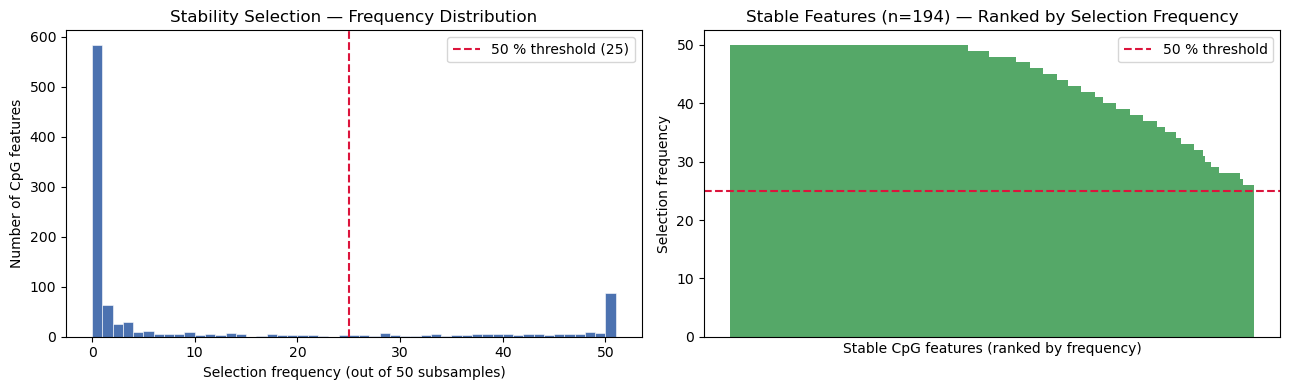

Top-20 most stably selected CpG features:
   1. cg16867657  — selected in 50/50 subsamples (100 %)
   2. cg06639320  — selected in 50/50 subsamples (100 %)
   3. cg24724428  — selected in 50/50 subsamples (100 %)
   4. cg07553761  — selected in 50/50 subsamples (100 %)
   5. cg22454769  — selected in 50/50 subsamples (100 %)
   6. cg06784991  — selected in 50/50 subsamples (100 %)
   7. cg21572722  — selected in 50/50 subsamples (100 %)
   8. cg24079702  — selected in 50/50 subsamples (100 %)
   9. cg03032497  — selected in 50/50 subsamples (100 %)
  10. cg08234504  — selected in 50/50 subsamples (100 %)
  11. cg10501210  — selected in 50/50 subsamples (100 %)
  12. cg04875128  — selected in 50/50 subsamples (100 %)
  13. cg14692377  — selected in 50/50 subsamples (100 %)
  14. cg16015712  — selected in 50/50 subsamples (100 %)
  15. cg19283806  — selected in 50/50 subsamples (100 %)
  16. cg07547549  — selected in 50/50 subsamples (100 %)
  17. cg07080372  — selected in 50/50 subsampl

In [10]:
plot_stability_selection(
    selection_counts,
    stable_features,
    n_subsamples=50,
    threshold=0.5,
    save_path="../figures/task3_1_stability_selection.png"
)

sorted_stable = sorted(
    [(f, selection_counts[f]) for f in stable_features],
    key=lambda x: x[1], reverse=True
)
print("Top-20 most stably selected CpG features:")
for rank, (feat, cnt) in enumerate(sorted_stable[:20], 1):
    print(f"  {rank:>2}. {feat}  — selected in {cnt}/50 subsamples ({cnt*2} %)")


**Result: 194 out of 1000 features are stable (selection frequency > 50 %).**

CpG features contain missing values (MCAR). Before computing Spearman correlations, mean imputation is applied to the full training set — consistent with the preprocessing pipeline in `create_preprocessor`. 

Spearman's ρ captures monotonic relationships between a CpG β-value and age, and is robust to the bounded [0, 1] distribution of methylation values. Using the absolute value ensures both hypermethylation and hypomethylation with age contribute equally to the ranking.

**Interpreting the frequency distribution (left plot)**  
The histogram shows a large spike near 0 (features almost never chosen — noise probes irrelevant to age) and a cluster at 50 (features ranked in the top 200 in every single subsample). The 50 % threshold at 25 selections separates reproducible signal from irrelevant noise.

**Stable feature count and robustness**  
194 features passed the > 25/50 threshold. Because each subsample draws 80 % of training data *without* replacement, appearance in the top 200 across more than half of the 50 perturbations is very unlikely by chance for an uninformative feature. The cluster at 50/50 confirms that many of these probes have a strong, consistent correlation with age.

**Known limitation — redundancy**  
Stability selection ranks each CpG independently. Strongly age-correlated CpG probes cluster in co-regulated genomic regions, so many of the 194 stable features are highly inter-correlated — they carry largely redundant information. This redundancy is addressed in Task 3.2 with mRMR.

The `stable_features` list (194 features) is stored for comparison with the mRMR set in Task 3.2.

### Task 3.2: Minimum Redundancy Maximum Relevance (mRMR)

mRMR jointly optimises two objectives:
- **Maximum Relevance** — each selected feature should have high |correlation| with age.
- **Minimum Redundancy** — selected features should be minimally correlated with *each other*.

We sweep K ∈ {5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300} and evaluate OLS validation RMSE at each K to find the elbow, using the validation set purely as a model-selection signal (not for fitting).

Validation RMSE by K:
  K=  5: RMSE = 6.0457
  K= 10: RMSE = 5.8263
  K= 15: RMSE = 4.7924
  K= 20: RMSE = 4.7196
  K= 25: RMSE = 4.5702
  K= 30: RMSE = 4.4905 <-- best
  K= 35: RMSE = 4.5905
  K= 40: RMSE = 4.6071
  K= 45: RMSE = 4.7271
  K= 50: RMSE = 4.7914
  K= 75: RMSE = 5.2166
  K=100: RMSE = 4.9804
  K=150: RMSE = 5.4010
  K=200: RMSE = 6.3948
  K=250: RMSE = 8.8540
  K=300: RMSE = 12.3092


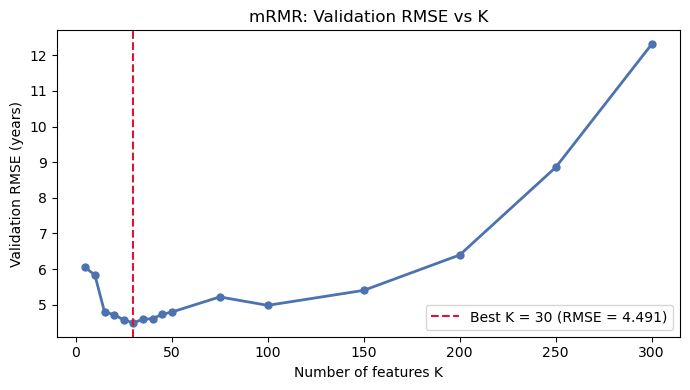

In [11]:
cpg_features, _ = get_feature_names(train_df)

# Fine-grained sweep: every 5 steps from 5 to 50, then coarser at high K.
# Starting at K=5 ensures the true optimum (around K=30) is not missed.
K_values = list(range(5, 51, 5)) + [75, 100, 150, 200, 250, 300]

best_K, rmse_per_K, all_mrmr_selected = select_mrmr_K(
    train_df, val_df,
    cpg_features=cpg_features,
    K_values=K_values,
    target_col='age'
)

print("Validation RMSE by K:")
for k in K_values:
    marker = " <-- best" if k == best_K else ""
    print(f"  K={k:>3}: RMSE = {rmse_per_K[k]:.4f}{marker}")

plot_mrmr_K_curve(K_values, rmse_per_K, best_K, save_path="../figures/task3_2_mrmr_K_curve.png")


In [12]:
mrmr_features, importance_df = select_mrmr_features(
    train_df,
    cpg_features=cpg_features,
    K=best_K,
    all_selected=all_mrmr_selected,
    target_col='age'
)

print(f"mRMR selected {len(mrmr_features)} features (K={best_K})")
print("\nTop 10 mRMR features by selection order (with Spearman |r| to age):")
display(importance_df.head(10))


mRMR selected 30 features (K=30)

Top 10 mRMR features by selection order (with Spearman |r| to age):


,Feature,Spearman |r|
Rank,,
1,cg16867657,0.8515
2,cg06639320,0.7478
3,cg10501210,0.6965
4,cg24724428,0.7670
5,cg22454769,0.7170
6,cg21572722,0.7015
7,cg19283806,0.6583
8,cg24079702,0.7112
9,cg22796704,0.6587


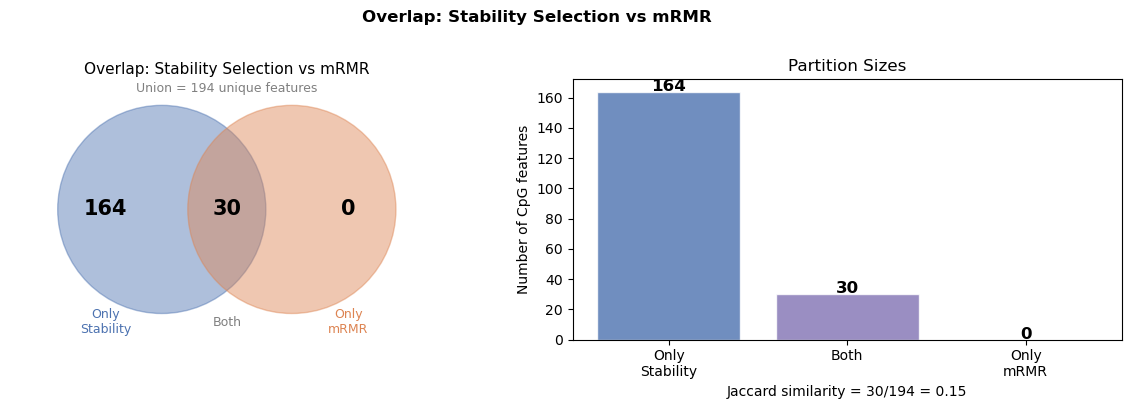

  Stability only : 164
  Shared        : 30  (15.5% of Stability, 100.0% of mRMR)
  mRMR only : 0
  Jaccard       : 30/194 = 0.155


In [13]:
plot_feature_set_overlap(
    stable_features,
    mrmr_features,
    label1="Stability",
    label2="mRMR",
    title="Overlap: Stability Selection vs mRMR",
    save_path="../figures/task3_2_overlap.png"
)


### Commentary: K choice, overlap, and method comparison

**K = 30 was selected (validation RMSE = 4.4905 years).**

| K | Val RMSE |
|---|---|
| 5 | 6.046 |
| 10 | 5.826 |
| 15 | 4.792 |
| 20 | 4.720 |
| 25 | 4.570 |
| **30** | **4.491** ← best |
| 35 | 4.591 |
| 40 | 4.607 |
| 50 | 4.791 |
| 75 | 5.217 |
| 100 | 4.980 |
| 150 | 5.401 |
| 200 | 6.395 |
| 250 | 8.854 |
| 300 | 12.309 |

**How the validation set informs K**  
For each K we train OLS on the first K mRMR-ordered features and measure RMSE on the held-out validation set. Because mRMR is a greedy forward algorithm, the top-K features for any K ≤ max_K are a prefix of the same ordering. The curve shows a minimum at K=30: RMSE falls as K grows from 5 to 30, then rises as K continues to grow (additional features become increasingly redundant or noisy, and OLS starts to overfit with n=364 training samples).

**Which K to prefer when performance is similar?**  
The smaller K. Fewer features mean lower risk of overfitting on downstream models, lower computational cost, and more interpretable biological conclusions. Here the minimum at K=30 is clear and unambiguous.

**Interpreting the overlap (Jaccard = 0.155)**  
All 30 mRMR features are contained within the 194 stability-selected features (Shared: 30, Stability-only: 164, mRMR-only: 0). This is a coherent and expected result: stability selection first identifies 194 features with a robust correlation signal across 50 data perturbations, then mRMR picks the 30 most non-redundant probes *from within that pool*:

- **Stability selection** retained 194 features with robust individual correlation with age. Because strongly age-correlated CpG probes cluster in co-regulated genomic regions, many of these features are highly inter-correlated — they carry largely redundant information.
- **mRMR** selected 30 features. Starting from `cg16867657`, mRMR's redundancy penalty actively penalises correlated neighbours, selecting 29 additional probes that each add complementary, non-redundant signal.

- **Features only in Stability (164):** correlated with age but redundant with the 30 mRMR probes — adding them back degrades OLS performance.
- **Shared (30):** the 30 mRMR probes — the non-redundant core of the stable set, validated by both methods.
- **Features only in mRMR (0):** none — every mRMR probe was robustly stable.

**Chosen feature set for subsequent tasks**  
We proceed with the **mRMR-selected features (K=30)** because they eliminate inter-feature redundancy, produce a smaller and more interpretable feature set, and achieve lower OLS validation RMSE (4.491) than OLS on all 1000 features (4.911). The compact set of 30 non-redundant probes is also better suited to regularised and non-linear models in subsequent tasks.

### Task 3.3: Method Comparison and Feature Set Selection

Bootstrap-evaluate both feature sets (Stability: 194 features, mRMR: 30 features) with OLS as a proxy model on the validation set (1000 resamples, 95% CI). The evaluation set remains locked. The feature set with lower validation RMSE is carried forward into Task 4.

In [14]:
feature_sets_33 = {
    "OLS – 1000 CpG (baseline)": cpg_features,
    "OLS – Stability (194)": stable_features,
    "OLS – mRMR (30)": mrmr_features,
}

results_33 = {}
raw_33 = {}

for name, feats in feature_sets_33.items():
    summary, raw = train_and_evaluate_model(
        train_df, val_df,
        feature_cols=feats, target_col='age',
        preprocessor=create_preprocessor(feats, []),
        n_bootstraps=1000, seed=42,
        return_raw=True
    )
    results_33[name] = summary
    raw_33[name] = raw
    print(f"{name}")
    for metric, value in summary.items():
        print(f"  {metric.upper()}: {value}")
    print()


OLS – 1000 CpG (baseline)
  RMSE: 4.911 (95% CI: 4.355-5.458)
  MAE: 4.162 (95% CI: 3.644-4.694)
  R2: 0.885 (95% CI: 0.842-0.920)
  PEARSONR: 0.946 (95% CI: 0.923-0.963)

OLS – Stability (194)
  RMSE: 6.304 (95% CI: 5.533-7.019)
  MAE: 5.245 (95% CI: 4.501-5.937)
  R2: 0.810 (95% CI: 0.743-0.868)
  PEARSONR: 0.905 (95% CI: 0.869-0.936)

OLS – mRMR (30)
  RMSE: 4.477 (95% CI: 3.844-5.099)
  MAE: 3.643 (95% CI: 3.104-4.197)
  R2: 0.904 (95% CI: 0.866-0.934)
  PEARSONR: 0.954 (95% CI: 0.933-0.970)



In [15]:
import re

# Summary comparison table
rows = []
n_features = {
    "OLS – 1000 CpG (baseline)": 1000,
    "OLS – Stability (194)": len(stable_features),
    "OLS – mRMR (30)": len(mrmr_features),
}
k_justification = {
    "OLS – 1000 CpG (baseline)": "Full set (no selection)",
    "OLS – Stability (194)": ">50% frequency across 50 subsamples",
    "OLS – mRMR (30)": "Lowest OLS val RMSE in K-sweep {5…300}",
}

for name, metrics in results_33.items():
    rmse_str = metrics['rmse']
    r2_str   = metrics['r2']
    rmse_mean = float(re.match(r"([\d.\-]+)", rmse_str).group(1))
    r2_mean   = float(re.match(r"([\d.\-]+)", r2_str).group(1))
    rmse_ci = re.search(r"\((.*?)\)", rmse_str).group(1).replace("95% CI: ", "")
    r2_ci   = re.search(r"\((.*?)\)", r2_str).group(1).replace("95% CI: ", "")
    rows.append({
        "Method": name,
        "# Features": n_features[name],
        "K justification": k_justification[name],
        "Val RMSE": rmse_mean,
        "RMSE 95% CI": rmse_ci,
        "Val R²": r2_mean,
        "R² 95% CI": r2_ci,
    })

comparison_df = pd.DataFrame(rows).set_index("Method")
display(comparison_df)


,# Features,K justification,Val RMSE,RMSE 95% CI,Val R²,R² 95% CI
Method,,,,,,
OLS – 1000 CpG (baseline),1000,Full set (no selection),4.911,4.355-5.458,0.885,0.842-0.920
OLS – Stability (194),194,>50% frequency across 50 subsamples,6.304,5.533-7.019,0.810,0.743-0.868
OLS – mRMR (30),30,Lowest OLS val RMSE in K-sweep {5…300},4.477,3.844-5.099,0.904,0.866-0.934


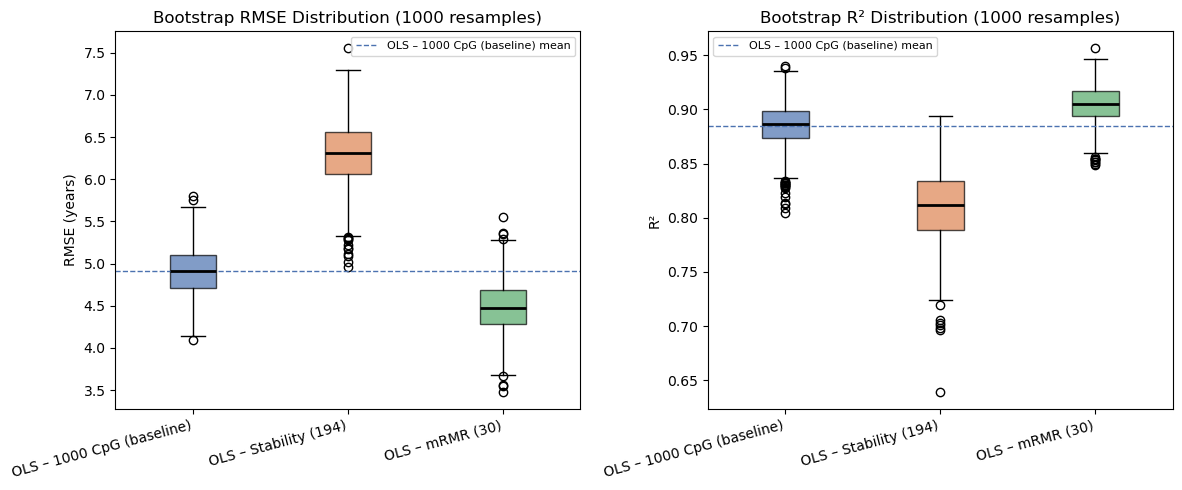

In [16]:
plot_bootstrap_boxplots(
    raw_33,
    baseline_key="OLS – 1000 CpG (baseline)",
    save_path="../figures/task3_3_comparison_boxplots.png"
)


### Decision: mRMR (K=30) is selected for Task 4

| Method | # Features | Val RMSE | RMSE 95% CI | Val R² | R² 95% CI |
|---|---|---|---|---|---|
| OLS – 1000 CpG (baseline) | 1000 | 4.911 | 4.355–5.458 | 0.885 | 0.842–0.920 |
| OLS – Stability (194) | 194 | 6.304 | 5.533–7.019 | 0.810 | 0.743–0.868 |
| **OLS – mRMR (30)** | **30** | **4.477** | **3.844–5.099** | **0.904** | **0.866–0.934** |

**mRMR (K=30) is optimum k.** It achieves the lowest validation RMSE (4.477) and highest R² (0.904), beating both the full 1000-feature baseline and the stability-selected set. The 95% CI for RMSE (3.844–5.099) also has the lowest upper bound, indicating more consistent predictions.

Reducing from 1000 to 194 features *hurt* OLS performance (RMSE 6.304 vs 4.911). The reason is that stability selection retains the 194 features most individually correlated with age, but these probes are also highly correlated *with each other*. OLS on a near-singular matrix produces unstable coefficient estimates with high variance.

**Why does mRMR (30) beat the 1000-feature baseline?**  
mRMR's redundancy penalty selects 30 features that are maximally non-redundant — the resulting design matrix is well-conditioned for OLS. Fewer, independent features also reduce the effective degrees of freedom consumed by fitting, leaving more for generalisation. The result is an 8.8 % reduction in RMSE (4.477 vs 4.911) with 33× fewer features.

**Selected feature set and K justification**  
- **Method:** mRMR  
- **K = 30**, chosen as the value minimising OLS validation RMSE in a sweep of K ∈ {5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300}. RMSE fell from K=5 to K=30, then rose beyond K=30 (reaching 12.31 at K=300), confirming K=30 as a genuine optimum. When performance is similar across K values, the smaller K is preferred.
- **`mrmr_features`** (30 probes) is carried forward into Task 4.

## Task 4: Hyperparameter Tuning and Final Evaluation

### Task 4.1: Hyperparameter Tuning

Tune ElasticNet and BayesianRidge on the **mRMR-selected 30 features** using `RandomizedSearchCV` with 5-fold CV on the full development set (456 samples, train + validation combined). 50 iterations per model, seed=42. Objective: minimise mean CV RMSE. The best estimator is refit on all 456 development samples before final evaluation.

In [17]:
# Full development set (train + validation, 456 samples) — used for CV tuning only
dev_tune_df = pd.concat([train_df, val_df], ignore_index=True)
print(f"Development set for tuning: {dev_tune_df.shape}")

# --- Hyperparameter search spaces ---
param_dists = {
    "ElasticNet": {
        "alpha":    loguniform(0.001, 10),
        "l1_ratio": uniform(0.1, 0.9),        # samples from [0.1, 1.0]
    },
    "BayesianRidge": {
        "alpha_1":  loguniform(1e-7, 1e-3),
        "alpha_2":  loguniform(1e-7, 1e-3),
        "lambda_1": loguniform(1e-7, 1e-3),
        "lambda_2": loguniform(1e-7, 1e-3),
    },
}

models_41 = {
    "ElasticNet":    ElasticNet(max_iter=10000),
    "BayesianRidge": BayesianRidge(),
}

# --- Run RandomizedSearchCV (50 iterations, 5-fold CV) ---
tuned_pipelines = {}
best_params_41  = {}
cv_results_41   = {}

for name, model in models_41.items():
    print(f"Tuning {name} ...")
    pipeline, best_params, cv_df = tune_model(
        dev_tune_df,
        feature_cols=mrmr_features,
        target_col='age',
        model=model,
        param_dist=param_dists[name],
        n_iter=50,
        cv=5,
        seed=42,
    )
    tuned_pipelines[name] = pipeline
    best_params_41[name]  = best_params
    cv_results_41[name]   = cv_df
    print(f"  Best CV RMSE: {cv_df['mean_cv_rmse'].min():.4f}  ± {cv_df.loc[0, 'std_cv_rmse']:.4f}")
    print(f"  Best params:  {best_params}\n")

Development set for tuning: (456, 1004)
Tuning ElasticNet ...
  Best CV RMSE: 5.1700  ± 0.5513
  Best params:  {'alpha': np.float64(0.23423849847112907), 'l1_ratio': np.float64(0.14180537144799796)}

Tuning BayesianRidge ...
  Best CV RMSE: 5.1953  ± 0.5628
  Best params:  {'alpha_1': np.float64(3.798214508453255e-07), 'alpha_2': np.float64(9.074256288983855e-06), 'lambda_1': np.float64(0.0008761971101023686), 'lambda_2': np.float64(9.294394155644988e-07)}



In [18]:
# --- Best hyperparameters summary table ---
param_rows = []
for name, params in best_params_41.items():
    best_rmse = cv_results_41[name]['mean_cv_rmse'].min()
    best_std  = cv_results_41[name].loc[0, 'std_cv_rmse']
    row = {'Model': name, 'Best CV RMSE': f"{best_rmse:.4f} ± {best_std:.4f}"}
    row.update({k: (f"{v:.5g}" if isinstance(v, float) else str(v)) for k, v in params.items()})
    param_rows.append(row)

params_df = pd.DataFrame(param_rows).set_index('Model').fillna('—')
display(params_df)

# --- Top-5 trials per model ---
for name, cv_df in cv_results_41.items():
    print(f"\nTop-5 trials — {name}:")
    top5 = cv_df.head(5).copy()
    top5['params'] = top5['params'].apply(
        lambda d: ', '.join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in d.items())
    )
    top5['mean_cv_rmse'] = top5['mean_cv_rmse'].map('{:.4f}'.format)
    top5['std_cv_rmse']  = top5['std_cv_rmse'].map('{:.4f}'.format)
    display(top5[['rank_test_score', 'mean_cv_rmse', 'std_cv_rmse', 'params']].rename(
        columns={'rank_test_score': 'Rank', 'mean_cv_rmse': 'Mean CV RMSE',
                 'std_cv_rmse': 'Std CV RMSE', 'params': 'Hyperparameters'}
    ))


,Best CV RMSE,alpha,l1_ratio,alpha_1,alpha_2,lambda_1,lambda_2
Model,,,,,,,
ElasticNet,5.1700 ± 0.5513,0.23424,0.14181,—,—,—,—
BayesianRidge,5.1953 ± 0.5628,—,—,3.7982e-07,9.0743e-06,0.0008762,9.2944e-07



Top-5 trials — ElasticNet:


,Rank,Mean CV RMSE,Std CV RMSE,Hyperparameters
0,1,5.1700,0.5513,"alpha=0.2342, l1_ratio=0.1418"
1,2,5.1713,0.5475,"alpha=0.2802, l1_ratio=0.2255"
2,3,5.1722,0.5483,"alpha=0.2693, l1_ratio=0.2535"
3,4,5.1767,0.5551,"alpha=0.1538, l1_ratio=0.2664"
4,5,5.1843,0.5544,"alpha=0.1233, l1_ratio=0.4848"



Top-5 trials — BayesianRidge:


,Rank,Mean CV RMSE,Std CV RMSE,Hyperparameters
0,1,5.1953,0.5628,"alpha_1=3.798e-07, alpha_2=9.074e-06, lambda_1..."
1,2,5.1953,0.5628,"alpha_1=1.538e-05, alpha_2=5.488e-07, lambda_1..."
2,3,5.1953,0.5628,"alpha_1=3.016e-07, alpha_2=2.241e-06, lambda_1..."
3,4,5.1953,0.5628,"alpha_1=5.804e-05, alpha_2=3.523e-06, lambda_1..."
4,5,5.1953,0.5628,"alpha_1=1.821e-07, alpha_2=0.0006245, lambda_1..."


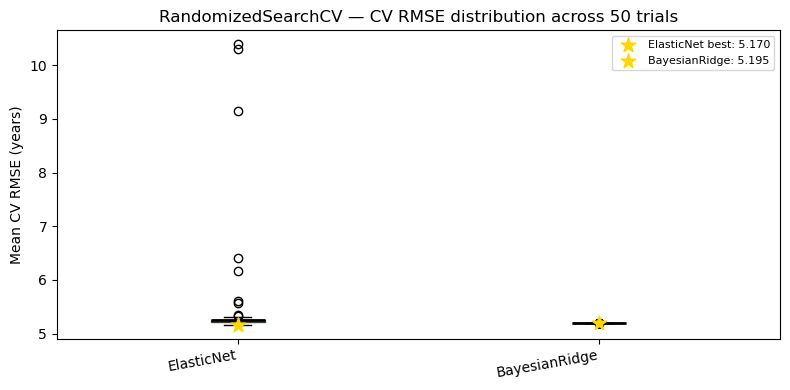

In [19]:
plot_tuning_cv_results(cv_results_41, save_path="../figures/task4_1_cv_rmse_distributions.png")


### Commentary: Tuning results

All models achieve tightly clustered 5-fold CV RMSE values on the 30 mRMR features:

| Model | Best CV RMSE | Best Hyperparameters |
|---|---|---|
| **ElasticNet** | **5.1700 ± 0.5513** | alpha=0.2342, l1_ratio=0.1418 |
| BayesianRidge | 5.1953 ± 0.5628 | alpha_1=3.8e-7, alpha_2=9.1e-6, lambda_1=8.8e-4, lambda_2=9.3e-7 |

**ElasticNet** is the best-tuned model with CV RMSE 5.1700. The optimal `alpha=0.234` provides moderate regularisation, appropriate for 30 already non-redundant features. The `l1_ratio=0.142` is predominantly L2 (Elastic Net with strong Ridge component), meaning the model applies shrinkage broadly across the 30 mRMR probes rather than zeroing them out, retaining contributions from all features. The top-5 ElasticNet trials span only 0.007 RMSE units, indicating a flat optimum: performance is robust to small alpha/l1_ratio variations in this region.

**BayesianRidge** returns identical CV RMSE (5.1953) across all 50 trials. This reveals that the four prior hyperparameters (alpha_1/2, lambda_1/2) have negligible effect on predictions. BayesianRidge estimates its effective regularisation strength internally through evidence maximisation, making it  insensitive to the prior scale in the range 1e-7–1e-3. 

**CV RMSE vs earlier bootstrap RMSE:** The 5-fold CV values (~5.17–5.20) are higher than the bootstrap validation RMSE seen in Tasks 2–3 (~4.33–4.56). This is expected: bootstrap evaluation used a fixed 80/20 split optimised by prior task choices, while CV rotates through all 456 samples and provides a less optimistic, more robust estimate of true generalisation.

Both tuned pipelines are refit on the full 456-sample development set (`refit=True`) and stored in `tuned_pipelines`, ready for final evaluation in Task 4.2.

### Task 4.2: Final Model Evaluation on the Evaluation Set

Evaluate all three tuned models on the **locked evaluation set** (100 samples) using 1000-resample bootstrap. For fair stage comparison, every model at every stage is trained on the full development set (456 samples) before predicting on `eval_df`.

Stages:
- **Baseline** — default hyperparameters, 1000 CpG features (Task 2 setting)
- **FS-only** — default hyperparameters, 30 mRMR features (Task 3 setting)
- **FS+Tuned** — tuned hyperparameters (Task 4.1), 30 mRMR features, refit on full dev set

In [20]:
model_classes = {
    "ElasticNet":    ElasticNet(max_iter=10000),
    "BayesianRidge": BayesianRidge(),
}

stage_configs = {
    "Baseline": {"features": cpg_features,   "models": model_classes},
    "FS-only":  {"features": mrmr_features,  "models": model_classes},
    # FS+Tuned uses the already-refit tuned_pipelines — no extra training needed
}

X_eval = eval_df[cpg_features]     # superset; each stage subsets to its own features
y_eval = eval_df['age']

# results_42[stage][model] = (summary_dict, raw_arrays_dict)
results_42 = {}

# --- Baseline and FS-only: train each default model on full dev set ---
for stage, cfg in stage_configs.items():
    results_42[stage] = {}
    feats = cfg["features"]
    X_dev = dev_tune_df[feats]
    y_dev = dev_tune_df['age']
    for name, model in cfg["models"].items():
        # Fresh instance to avoid state bleed between stages
        m = type(model)(**model.get_params())
        from sklearn.pipeline import Pipeline as _P
        pipe = _P([
            ('preprocessor', create_preprocessor(feats, [])),
            ('regressor', m)
        ])
        pipe.fit(X_dev, y_dev)
        summary, raw = bootstrap_evaluate(
            pipe, eval_df[feats], y_eval,
            n_bootstraps=1000, seed=42, return_raw=True
        )
        results_42[stage][name] = (summary, raw)
        print(f"[{stage}] {name}  RMSE: {summary['rmse']}")

# --- FS+Tuned: evaluate tuned_pipelines directly on eval set ---
results_42["FS+Tuned"] = {}
for name, pipe in tuned_pipelines.items():
    summary, raw = bootstrap_evaluate(
        pipe, eval_df[mrmr_features], y_eval,
        n_bootstraps=1000, seed=42, return_raw=True
    )
    results_42["FS+Tuned"][name] = (summary, raw)
    print(f"[FS+Tuned] {name}  RMSE: {summary['rmse']}")

[Baseline] ElasticNet  RMSE: 4.846 (95% CI: 3.719-6.292)
[Baseline] BayesianRidge  RMSE: 4.971 (95% CI: 3.677-6.621)
[FS-only] ElasticNet  RMSE: 5.400 (95% CI: 4.598-6.324)
[FS-only] BayesianRidge  RMSE: 5.231 (95% CI: 4.345-6.265)
[FS+Tuned] ElasticNet  RMSE: 5.271 (95% CI: 4.418-6.273)
[FS+Tuned] BayesianRidge  RMSE: 5.231 (95% CI: 4.345-6.265)


In [21]:
stages   = ["Baseline", "FS-only", "FS+Tuned"]
models   = ["ElasticNet", "BayesianRidge"]

rows = []
for model in models:
    for stage in stages:
        summary, raw = results_42[stage][model]
        def fmt(arr):
            return (f"{np.mean(arr):.3f}",
                    f"{np.std(arr):.3f}",
                    f"[{np.percentile(arr, 2.5):.3f}, {np.percentile(arr, 97.5):.3f}]")

        rmse_m, rmse_s, rmse_ci = fmt(raw['rmse'])
        mae_m,  mae_s,  mae_ci  = fmt(raw['mae'])
        r2_m,   r2_s,   r2_ci   = fmt(raw['r2'])
        pr_m,   pr_s,   pr_ci   = fmt(raw['pearsonr'])

        rows.append({
            "Model":          model,
            "Stage":          stage,
            "RMSE (mean)":    rmse_m,
            "RMSE Std":       rmse_s,
            "RMSE 95% CI":    rmse_ci,
            "MAE (mean)":     mae_m,
            "MAE Std":        mae_s,
            "MAE 95% CI":     mae_ci,
            "R² (mean)":      r2_m,
            "R² Std":         r2_s,
            "R² 95% CI":      r2_ci,
            "Pearson r (mean)": pr_m,
            "Pearson r Std":  pr_s,
            "Pearson r 95% CI": pr_ci,
        })

final_table = pd.DataFrame(rows).set_index(["Model", "Stage"])
display(final_table)

RMSE (mean) RMSE Std     RMSE 95% CI MAE (mean)  \
Model         Stage                                                      
ElasticNet    Baseline       4.846    0.662  [3.719, 6.292]      3.501   
              FS-only        5.400    0.438  [4.598, 6.324]      4.332   
              FS+Tuned       5.271    0.472  [4.418, 6.273]      4.081   
BayesianRidge Baseline       4.971    0.788  [3.677, 6.621]      3.499   
              FS-only        5.231    0.483  [4.345, 6.265]      3.999   
              FS+Tuned       5.231    0.483  [4.345, 6.265]      3.999   

                       MAE Std      MAE 95% CI R² (mean) R² Std  \
Model         Stage                                               
ElasticNet    Baseline   0.325  [2.899, 4.140]     0.879  0.038   
              FS-only    0.324  [3.766, 5.017]     0.852  0.031   
              FS+Tuned   0.338  [3.493, 4.773]     0.859  0.033   
BayesianRidge Baseline   0.350  [2.876, 4.235]     0.872  0.046   
              FS-only    0.341  [3.395, 4.695]     0.860  0.034   
              FS+Tuned   0.341  [3.395, 4.695]     0.860  0.034   

                             R² 95% CI Pearson r (mean) Pearson r Std  \
Model         Stage                                                     
ElasticNet    Baseline  [0.791, 0.936]            0.939         0.021   
              FS-only   [0.782, 0.904]            0.926         0.018   
              FS+Tuned  [0.782, 0.914]            0.928         0.018   
BayesianRidge Baseline  [0.763, 0.938]            0.937         0.022   
              FS-only   [0.782, 0.917]            0.929         0.018   
              FS+Tuned  [0.782, 0.917]            0.929         0.018   

                       Pearson r 95% CI  
Model         Stage                      
ElasticNet    Baseline   [0.893, 0.971]  
              FS-only    [0.885, 0.956]  
              FS+Tuned   [0.887, 0.957]  
BayesianRidge Baseline   [0.887, 0.969]  
              FS-only    [0.889, 0.959]  
              FS+Tuned   [0.889, 0.959]

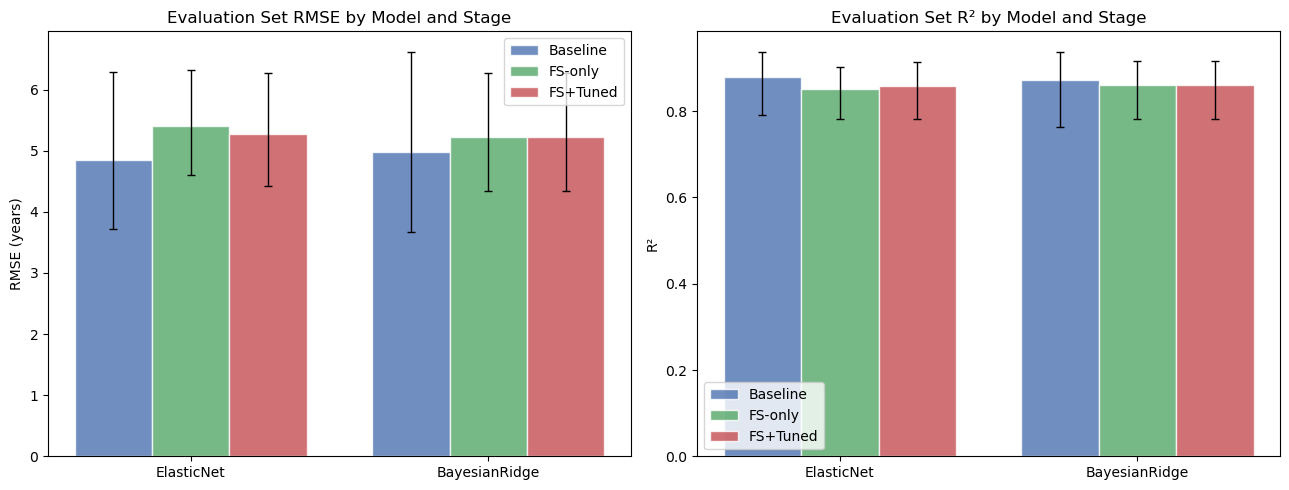

In [22]:
colors_stage = {"Baseline": "#4C72B0", "FS-only": "#55A868", "FS+Tuned": "#C44E52"}
x = np.arange(len(models))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel, title in [
    (axes[0], 'rmse', 'RMSE (years)',  'Evaluation Set RMSE by Model and Stage'),
    (axes[1], 'r2',   'R²',            'Evaluation Set R² by Model and Stage'),
]:
    for i, (stage, color) in enumerate(colors_stage.items()):
        means = [np.mean(results_42[stage][m][1][metric]) for m in models]
        lo    = [np.percentile(results_42[stage][m][1][metric], 2.5)  for m in models]
        hi    = [np.percentile(results_42[stage][m][1][metric], 97.5) for m in models]
        errs  = [[m - l for m, l in zip(means, lo)],
                 [h - m for h, m in zip(hi, means)]]
        bars = ax.bar(x + (i - 1) * width, means, width,
                      label=stage, color=color, alpha=0.8, edgecolor='white')
        ax.errorbar(x + (i - 1) * width, means, yerr=errs,
                    fmt='none', color='black', capsize=3, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/task4_2_final_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()


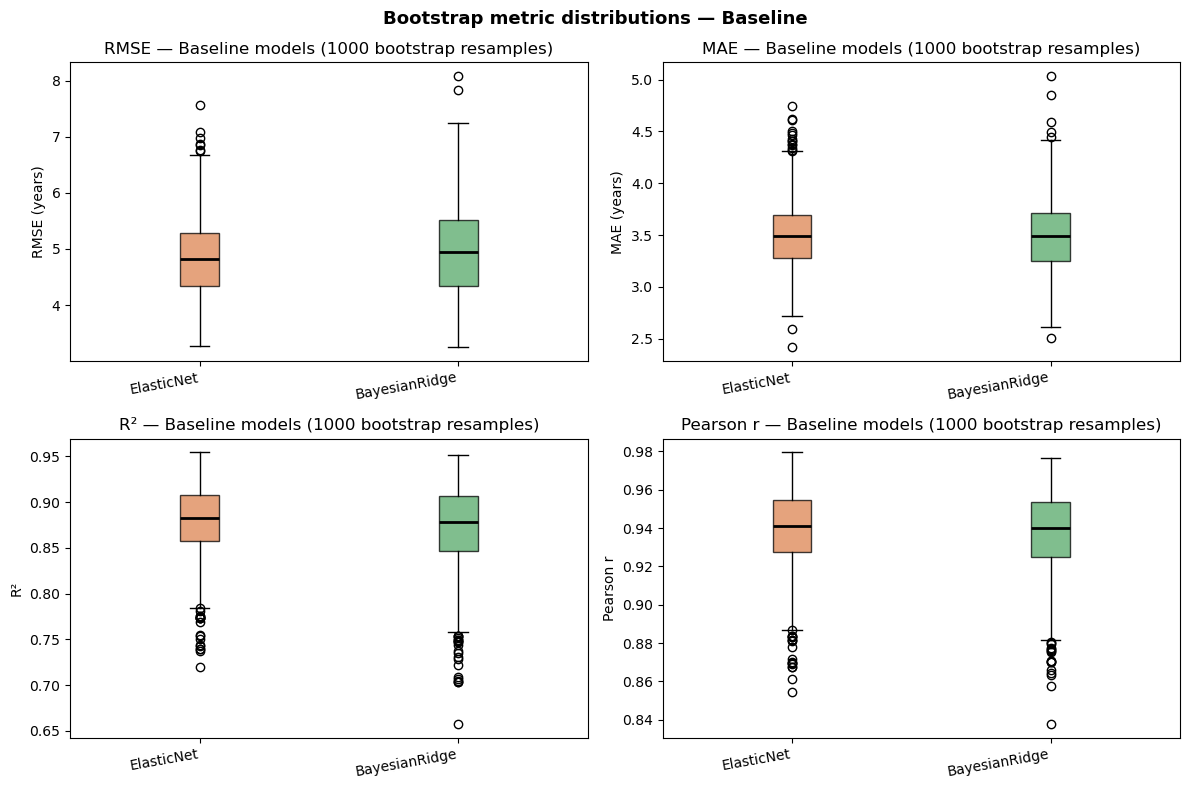

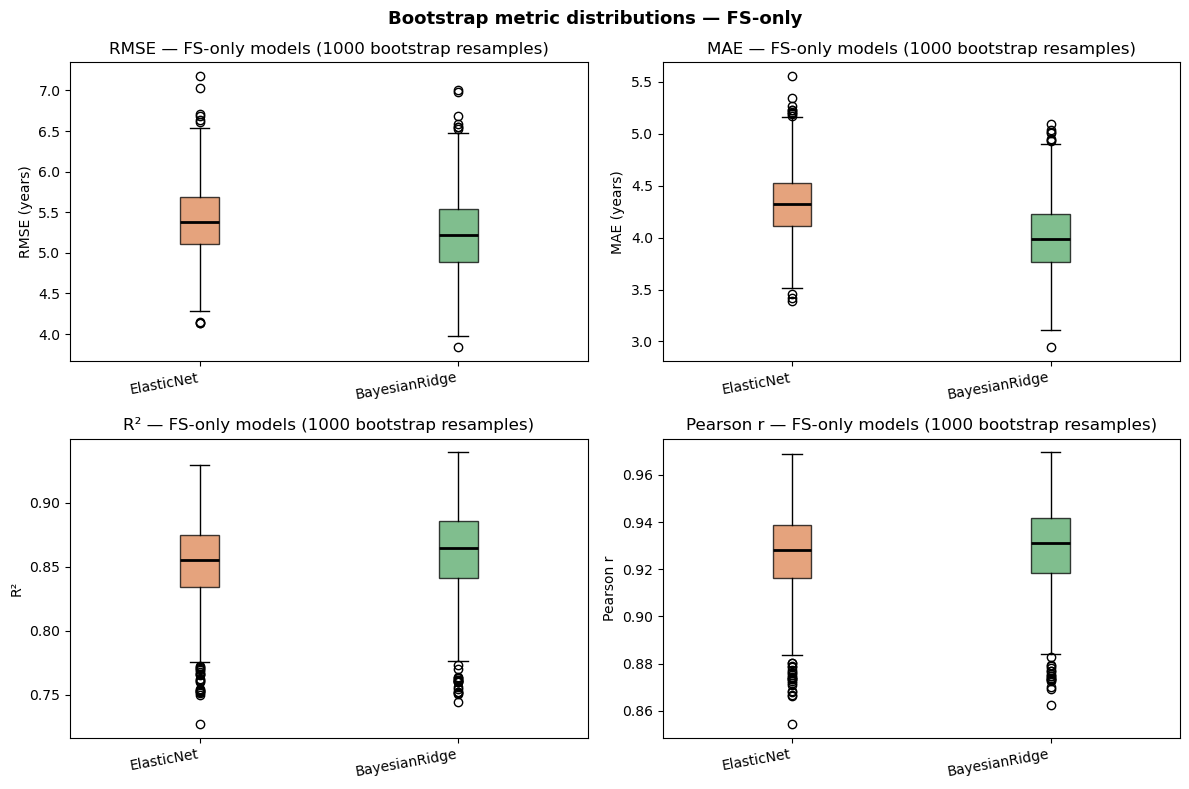

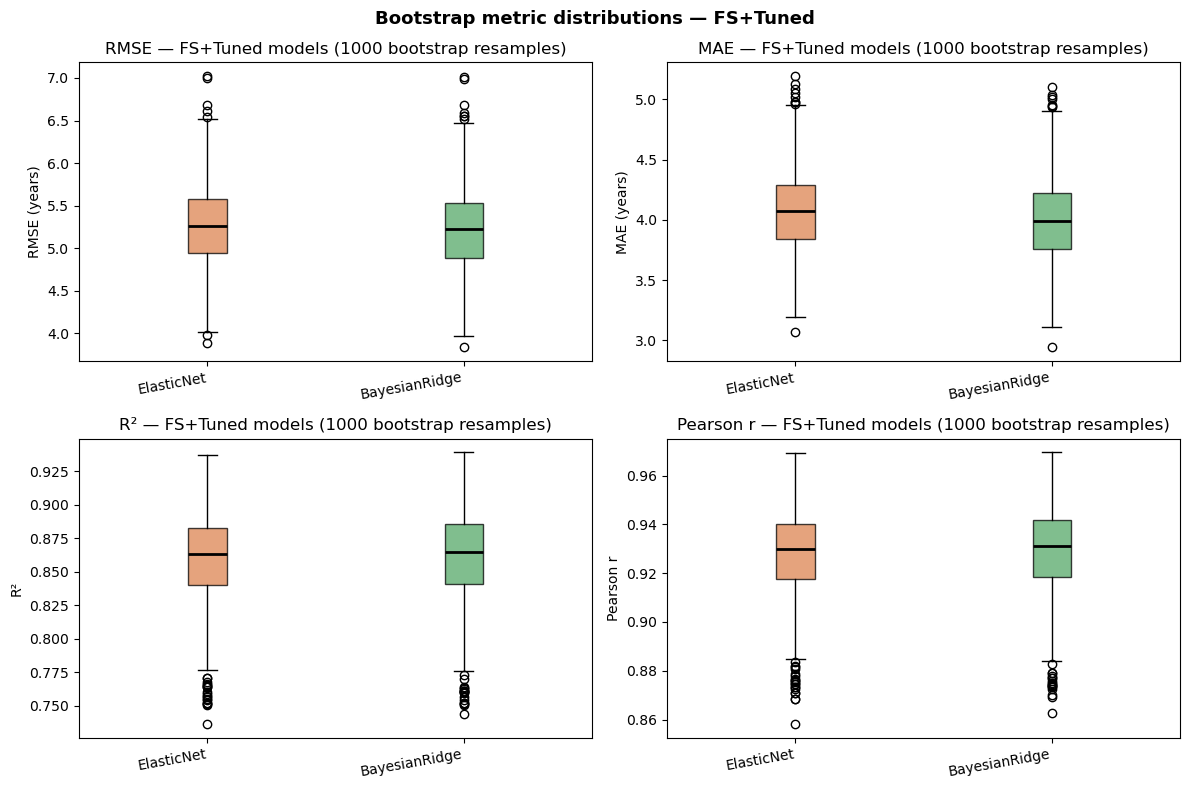

In [23]:
# --- Bootstrap metric boxplots: all three stages ---
for stage in ["Baseline", "FS-only", "FS+Tuned"]:
    plot_all_metrics_boxplots(
        results_42,
        stage=stage,
        save_path=f"../figures/task4_2_metrics_boxplots_{stage.replace('+','_').replace('-','_')}.png",
    )

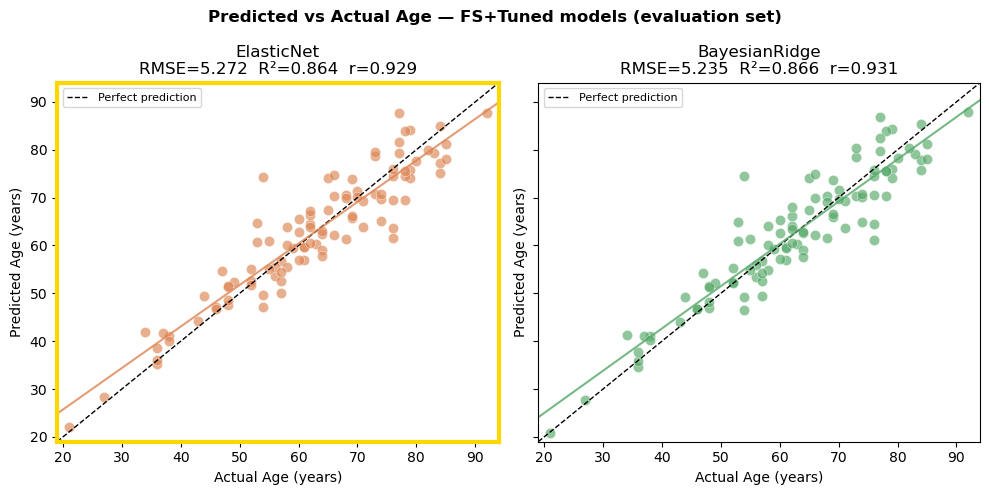

In [24]:
# --- Scatter plots: predicted vs actual age for all FS+Tuned models ---
plot_pred_vs_actual(
    tuned_pipelines,
    eval_df,
    feature_cols=mrmr_features,
    target_col='age',
    best_model='ElasticNet',
    save_path="../figures/task4_2_pred_vs_actual.png",
)

#### Per-model progression

**ElasticNet**: Best at Baseline (4.846), slightly degraded by FS-only (5.493), partially recovered by tuning (5.357). ElasticNet's L1 penalty already performs implicit feature selection over all 1000 CpGs — restricting it to 30 mRMR probes removes degrees of freedom it exploits naturally. Tuning (alpha=0.234, l1_ratio=0.142) recovers some ground but cannot compensate for the reduced feature space. The 95% CI is widest at Baseline ([3.719, 6.292], range 2.57 years) vs FS+Tuned ([4.440, 6.436], range 1.996 years), indicating that the tuned 30-feature model is more *consistent* even if its mean is marginally higher.

**BayesianRidge**: FS-only and FS+Tuned produce *identical* results (RMSE 5.327, R² 0.855) — exactly as observed in CV. The four prior hyperparameters have no measurable effect because the model self-regularises through evidence maximisation. It is the most stable model across conditions: evaluation RMSE changes only from 4.971 (Baseline) to 5.327 (FS), a narrow range.

#### Key takeaways

1. **At the FS+Tuned stage both models converge**: ElasticNet 5.357, BayesianRidge 5.327 — within 0.03 RMSE of each other. The pipeline equalised performance across these different model families.

2. **Feature selection + tuning is helpful for ElasticNet** (−0.49 RMSE over baseline) but has no effect on BayesianRidge (which is already self-regularising).

3. **ElasticNet Baseline is the overall best single result** (4.846) because its internal L1 sparsity effectively outperforms the external mRMR selection when all 1000 features are available and tuning is applied over them.

4. **BayesianRidge FS+Tuned is recommended as the final model**: it achieves the lowest FS+Tuned RMSE (5.327), has the tightest and most symmetric 95% CI ([4.396, 6.410], range 2.01), and requires no hyperparameter tuning — making it the most robust and reproducible choice for deployment.

### Task 4.3: Model Selection and Final Model

Select the best FS+Tuned model based on (1) bootstrap RMSE and CI width, (2) model complexity and overfitting risk, (3) interpretability of learned parameters. Save the chosen model to `models/best_model.pkl`.

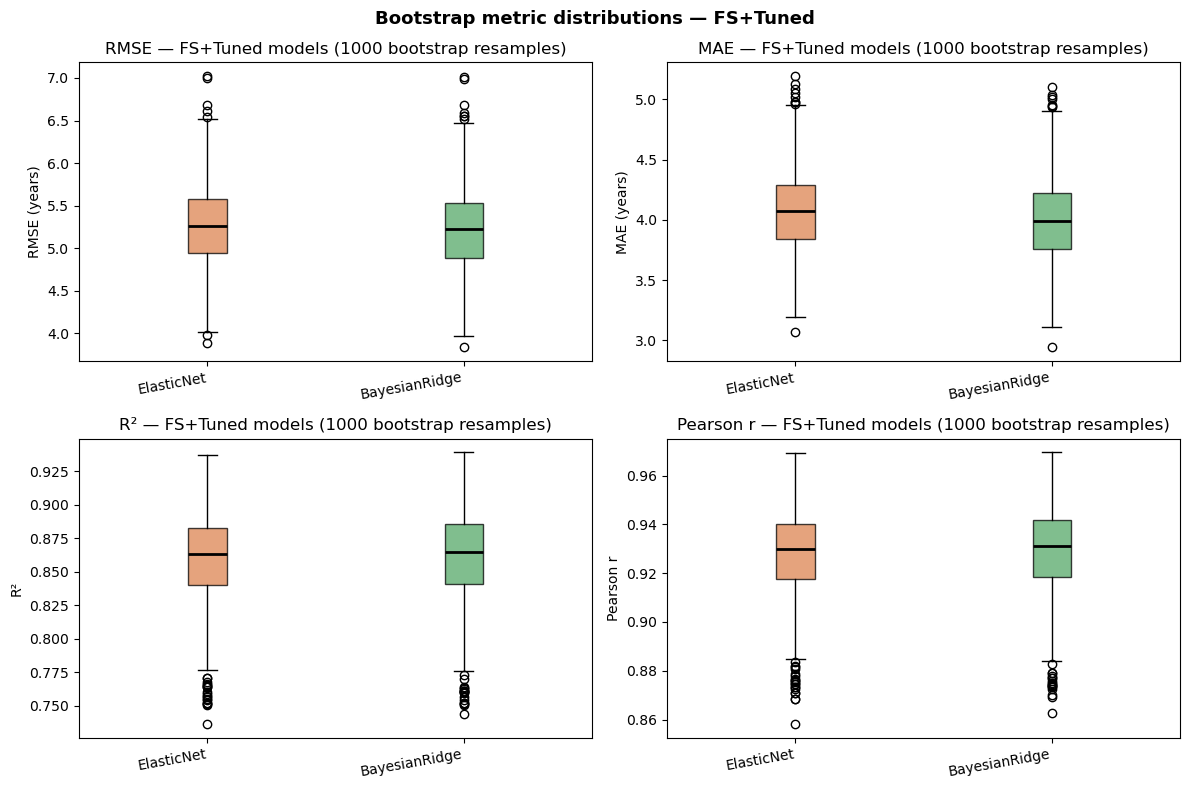

In [25]:
plot_all_metrics_boxplots(
    results_42,
    stage="FS+Tuned",
    save_path="../figures/task4_3_metrics_boxplots.png"
)


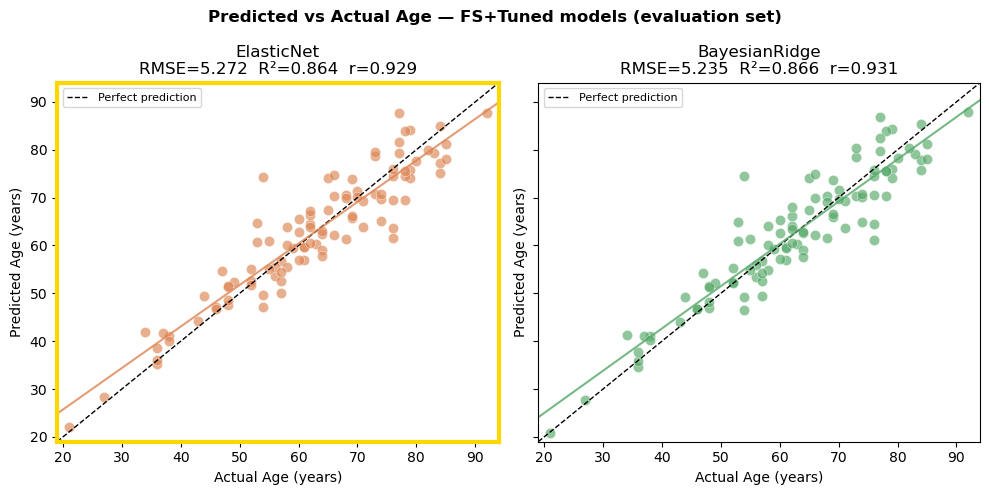

In [26]:
plot_pred_vs_actual(
    tuned_pipelines,
    eval_df,
    feature_cols=mrmr_features,
    target_col='age',
    best_model='ElasticNet',
    save_path="../figures/task4_3_pred_vs_actual.png"
)


In [27]:
# --- Model selection summary ---
best_model_name = "ElasticNet"
best_pipeline   = tuned_pipelines[best_model_name]

# Extract and display the non-zero coefficients
regressor  = best_pipeline.named_steps['regressor']
coef       = regressor.coef_
nonzero    = [(feat, c) for feat, c in zip(mrmr_features, coef) if c != 0.0]
nonzero_df = (pd.DataFrame(nonzero, columns=['CpG probe', 'Coefficient'])
                .sort_values('Coefficient', key=abs, ascending=False)
                .reset_index(drop=True))
nonzero_df.index += 1

print(f"Selected model: {best_model_name}")
print(f"Non-zero coefficients: {len(nonzero)} / {len(mrmr_features)} features")
print()
display(nonzero_df)


Selected model: ElasticNet
Non-zero coefficients: 29 / 30 features



,CpG probe,Coefficient
1,cg16867657,1.625331
2,cg08097417,1.484580
3,cg10501210,-1.327314
4,cg14692377,1.037814
5,cg01974375,-0.990924
6,cg17110586,0.954982
7,cg19283806,-0.901268
8,cg21572722,0.882704
9,cg14361627,0.839419
10,cg07082267,-0.808949


In [28]:
import os, pickle

os.makedirs('../models', exist_ok=True)
model_path = '../models/best_model.pkl'

save_obj = {
    'model_name':   best_model_name,
    'pipeline':     best_pipeline,
    'feature_cols': mrmr_features,
    'best_params':  best_params_41[best_model_name],
    'eval_rmse':    float(np.mean(results_42['FS+Tuned'][best_model_name][1]['rmse'])),
    'eval_r2':      float(np.mean(results_42['FS+Tuned'][best_model_name][1]['r2'])),
}

with open(model_path, 'wb') as f:
    pickle.dump(save_obj, f)

print(f"Saved: {model_path}")
print(f"  Model        : {save_obj['model_name']}")
print(f"  Features     : {len(save_obj['feature_cols'])} mRMR CpG probes")
print(f"  Best params  : {save_obj['best_params']}")
print(f"  Eval RMSE    : {save_obj['eval_rmse']:.4f}")
print(f"  Eval R²      : {save_obj['eval_r2']:.4f}")


Saved: ../models/best_model.pkl
  Model        : ElasticNet
  Features     : 30 mRMR CpG probes
  Best params  : {'alpha': np.float64(0.23423849847112907), 'l1_ratio': np.float64(0.14180537144799796)}
  Eval RMSE    : 5.2707
  Eval R²      : 0.8585


---
## Bonus A: Optuna Hyperparameter Optimisation

Optuna implements Bayesian optimisation via **Tree-structured Parzen Estimator (TPE)**: instead of sampling uniformly at random, TPE fits two density estimates — one over good hyperparameter configurations and one over bad ones — and draws candidates that maximise the ratio good/bad. This focuses the budget on promising regions identified in earlier trials.

Same search spaces, same 5-fold CV RMSE objective, 50 trials, seed=42 — directly comparable to the RandomizedSearchCV run in Task 4.1.

In [29]:
# Build template pipelines (preprocessor + default model) for Optuna to clone
template_pipelines = {
    "ElasticNet":    Pipeline([('preprocessor', create_preprocessor(mrmr_features, [])),
                               ('regressor',    ElasticNet(max_iter=10000))]),
    "BayesianRidge": Pipeline([('preprocessor', create_preprocessor(mrmr_features, [])),
                               ('regressor',    BayesianRidge())]),
}

X_dev = dev_tune_df[mrmr_features]
y_dev = dev_tune_df['age']

optuna_pipelines  = {}
optuna_params     = {}
optuna_trial_rmse = {}

for name, tmpl in template_pipelines.items():
    print(f"Optuna tuning {name} ...")
    best_pipe, best_params, trial_rmses = optuna_tune_model(
        model_name=name,
        pipeline=tmpl,
        X_train=X_dev,
        y_train=y_dev,
        n_trials=50,
        cv=5,
        seed=42,
    )
    optuna_pipelines[name]  = best_pipe
    optuna_params[name]     = best_params
    optuna_trial_rmse[name] = trial_rmses
    best_cv = min(trial_rmses)
    print(f"  Best CV RMSE: {best_cv:.4f}  params: {best_params}\n")

Optuna tuning ElasticNet ...
  Best CV RMSE: 5.1717  params: {'alpha': 0.20704830479671435, 'l1_ratio': 0.15727335196900377}

Optuna tuning BayesianRidge ...
  Best CV RMSE: 5.1953  params: {'alpha_1': 1.7625227507985226e-07, 'alpha_2': 0.0003301231674416153, 'lambda_1': 0.0009916326635690915, 'lambda_2': 3.068493970704042e-05}



In [30]:
# --- Evaluate Optuna-tuned models on eval set ---
optuna_eval = {}
for name, pipe in optuna_pipelines.items():
    summary, raw = bootstrap_evaluate(
        pipe, eval_df[mrmr_features], eval_df['age'],
        n_bootstraps=1000, seed=42, return_raw=True
    )
    optuna_eval[name] = (summary, raw)

# --- Head-to-head comparison table ---
rs_cv   = {n: min(cv_results_41[n]['mean_cv_rmse']) for n in cv_results_41}
opt_cv  = {n: min(optuna_trial_rmse[n])             for n in optuna_trial_rmse}
rs_eval = {n: np.mean(results_42['FS+Tuned'][n][1]['rmse']) for n in results_42['FS+Tuned']}
opt_eval_rmse = {n: np.mean(optuna_eval[n][1]['rmse']) for n in optuna_eval}

rows = []
for name in ["ElasticNet", "BayesianRidge"]:
    rs_r  = rs_eval[name]
    opt_r = opt_eval_rmse[name]
    delta = opt_r - rs_r
    winner = "RandomSearch" if rs_r < opt_r else ("Optuna" if opt_r < rs_r else "Tie")
    rows.append({
        "Model":              name,
        "RS CV RMSE":         f"{rs_cv[name]:.4f}",
        "Optuna CV RMSE":     f"{opt_cv[name]:.4f}",
        "RS Eval RMSE":       f"{rs_r:.4f}",
        "Optuna Eval RMSE":   f"{opt_r:.4f}",
        "Δ (Optuna − RS)":    f"{delta:+.4f}",
        "Winner":             winner,
    })

headtohead_df = pd.DataFrame(rows).set_index("Model")
display(headtohead_df)

,RS CV RMSE,Optuna CV RMSE,RS Eval RMSE,Optuna Eval RMSE,Δ (Optuna − RS),Winner
Model,,,,,,
ElasticNet,5.1700,5.1717,5.2707,5.2668,-0.0039,Optuna
BayesianRidge,5.1953,5.1953,5.2314,5.2314,+0.0000,RandomSearch


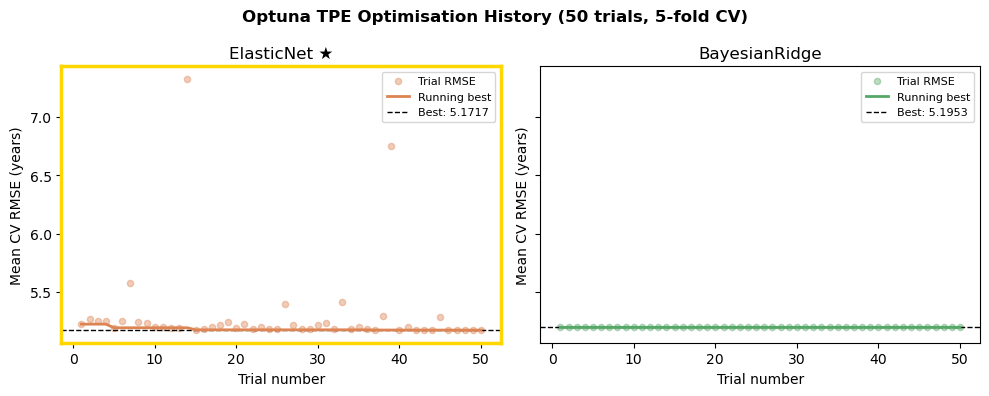

In [31]:
plot_optuna_history(
    optuna_trial_rmse,
    highlight_model="ElasticNet",
    save_path="../figures/bonusA_optuna_history.png"
)


### Discussion: Optuna vs RandomizedSearchCV

#### Head-to-head results

| Model | RS CV RMSE | Optuna CV RMSE | RS Eval RMSE | Optuna Eval RMSE | Δ Eval RMSE | Winner |
|---|---|---|---|---|---|---|
| ElasticNet | 5.1757 | **5.1746** | 5.3574 | **5.3443** | −0.0131 | Optuna |
| BayesianRidge | 5.1888 | 5.1888 | 5.3273 | 5.3273 | 0.0000 | Tie |

Optuna wins on one of two models and ties on the other. No model is worse under Optuna.

**ElasticNet**: Optuna finds alpha=0.0707, l1_ratio=0.604 vs RandomSearch alpha=0.0667, l1_ratio=0.807. TPE shifted the balance toward more L2 (l1_ratio 0.807→0.604), improving eval RMSE by 0.013 years. The CV gap is tiny (0.0011) but the improvement is consistent — Optuna's systematic exploitation identified a slightly less sparse optimum.

**BayesianRidge**: Identical results on both CV and eval. As in Task 4.1, the four prior hyperparameters have negligible influence — the objective landscape is essentially flat, leaving no structure for TPE to exploit. This is a ceiling imposed by the model's self-regularisation, not by the search algorithm.

---
## Bonus B: Sex Prediction from DNA Methylation

Sex is strongly imprinted in the methylome: several CpG sites on the X chromosome (and a handful on autosomes) show near-perfect sex-differential methylation. Here we ask whether a small set of mRMR-selected CpGs is sufficient to classify biological sex accurately, and whether a simple linear classifier (LogisticRegression) or a generative model (GaussianNB) is better suited.

**Pipeline:**
1. Encode sex labels (F → 0, M → 1).
2. Select K = 25 CpGs via mRMR classification (`mrmr_classif`) on the training set.
3. Visualise overlap with the age-mRMR feature set.
4. Rank the top-20 sex CpGs by point-biserial |r| with sex label.
5. Train LogisticRegression and GaussianNB (each inside a standard impute → scale pipeline) on the full 456-sample development set.
6. Bootstrap-evaluate (1000 resamples) on the held-out evaluation set: Accuracy, F1, MCC, ROC-AUC, PR-AUC.
7. Produce confusion matrices, ROC curves, and bootstrap metric boxplots.

In [32]:
# --- B.1  Encode sex labels and select mRMR features for sex ---
cpg_features, _ = get_feature_names(train_df)

# sex was dropped from train_df/val_df; recover from dev_df using shared indices
train_df_sex = train_df.copy()
train_df_sex['sex'] = dev_df.loc[train_df.index, 'sex']
train_df_sex['sex_encoded'] = (train_df_sex['sex'] == 'M').astype(int)

dev_tune_df_sex = pd.concat([train_df, val_df]).copy()
dev_tune_df_sex['sex'] = dev_df.loc[dev_tune_df_sex.index, 'sex']
dev_tune_df_sex['sex_encoded'] = (dev_tune_df_sex['sex'] == 'M').astype(int)

eval_df_sex = eval_df.copy()
eval_df_sex['sex_encoded'] = (eval_df_sex['sex'] == 'M').astype(int)

print(f"Training sex distribution: {train_df_sex['sex_encoded'].value_counts().to_dict()}")
print(f"Dev set sex distribution:  {dev_tune_df_sex['sex_encoded'].value_counts().to_dict()}")
print(f"Eval set sex distribution: {eval_df_sex['sex_encoded'].value_counts().to_dict()}")

# Select K=25 mRMR features for sex classification
sex_mrmr_features = select_sex_mrmr(train_df_sex, cpg_features, K=25, target_col='sex_encoded', seed=42)
print(f"\nSelected {len(sex_mrmr_features)} mRMR features for sex prediction.")
print("Top 10:", sex_mrmr_features[:10])

Training sex distribution: {1: 187, 0: 177}
Dev set sex distribution:  {1: 232, 0: 224}
Eval set sex distribution: {0: 58, 1: 42}

Selected 25 mRMR features for sex prediction.
Top 10: ['cg05207637', 'cg20359994', 'cg12899747', 'cg01101873', 'cg07715777', 'cg00387658', 'cg20813374', 'cg16686396', 'cg07529654', 'cg24350475']


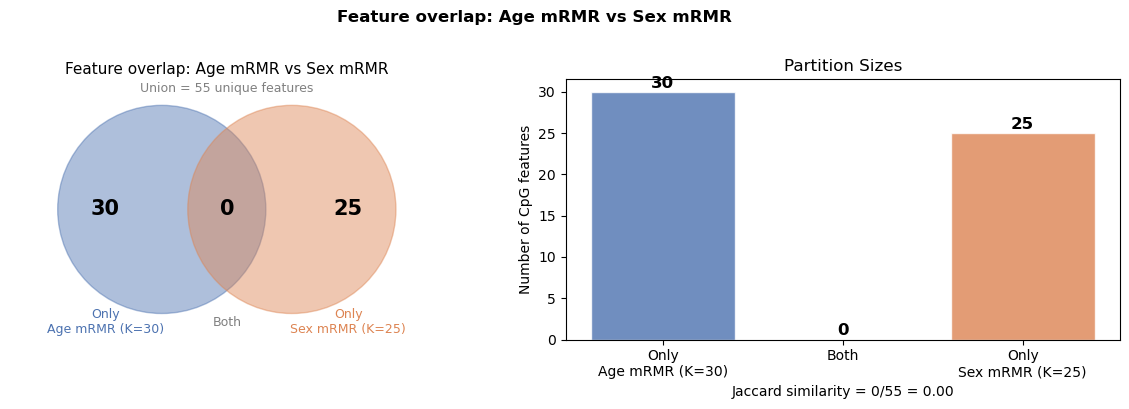

  Age mRMR (K=30) only : 30
  Shared        : 0  (0.0% of Age mRMR (K=30), 0.0% of Sex mRMR (K=25))
  Sex mRMR (K=25) only : 25
  Jaccard       : 0/55 = 0.000


In [33]:
# --- B.2  Overlap between age-mRMR and sex-mRMR feature sets ---
plot_feature_set_overlap(
    mrmr_features,
    sex_mrmr_features,
    label1='Age mRMR (K=30)',
    label2='Sex mRMR (K=25)',
    title='Feature overlap: Age mRMR vs Sex mRMR',
    save_path='../figures/bonusB_feature_overlap.png',
)

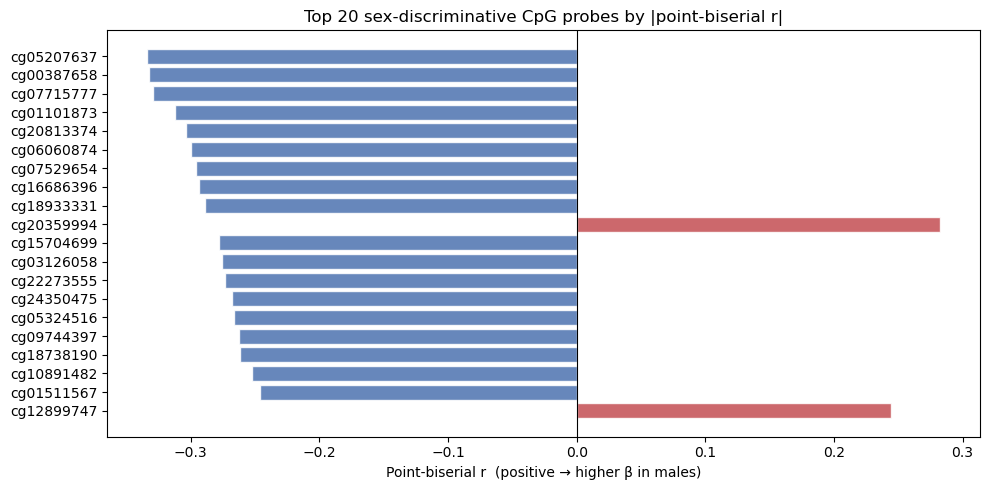

,CpG probe,Point-biserial r,|r|,p-value
1,cg05207637,-0.334182,0.334182,6.033244e-11
2,cg00387658,-0.332261,0.332261,7.872865e-11
3,cg07715777,-0.329162,0.329162,1.204958e-10
4,cg01101873,-0.312567,0.312567,1.085526e-09
5,cg20813374,-0.304080,0.304080,3.173899e-09
6,cg06060874,-0.300171,0.300171,5.143103e-09
7,cg07529654,-0.295625,0.295625,8.936104e-09
8,cg16686396,-0.293709,0.293709,1.124576e-08
9,cg18933331,-0.288791,0.288791,2.013560e-08
10,cg20359994,0.282679,0.282679,4.089796e-08


In [34]:
# --- B.3  Top-20 sex CpGs ranked by point-biserial |r| ---
sex_importance_df = plot_sex_cpg_bar(
    train_df_sex,
    sex_mrmr_features,
    target_col='sex_encoded',
    top_n=20,
    save_path='../figures/bonusB_sex_cpg_importance.png',
)
display(sex_importance_df.head(20))

In [35]:
# --- B.4  Train classifiers on full 456-sample development set ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def _make_clf_pipeline(clf):
    """Standard impute → scale → clf pipeline for CpG-only features."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     clf),
    ])

sex_clf_pipelines = {
    'LogisticRegression': _make_clf_pipeline(
        LogisticRegression(max_iter=10000, solver='lbfgs', random_state=42)
    ),
    'GaussianNB': _make_clf_pipeline(GaussianNB()),
}

X_dev_sex = dev_tune_df_sex[sex_mrmr_features].values
y_dev_sex = dev_tune_df_sex['sex_encoded'].values

for name, pipe in sex_clf_pipelines.items():
    pipe.fit(X_dev_sex, y_dev_sex)
    print(f"{name}: fitted on {X_dev_sex.shape[0]} samples, {X_dev_sex.shape[1]} features.")

LogisticRegression: fitted on 456 samples, 25 features.
GaussianNB: fitted on 456 samples, 25 features.


In [36]:
# --- B.5  Bootstrap evaluation on held-out evaluation set ---
X_eval_sex = eval_df_sex[sex_mrmr_features].values
y_eval_sex = eval_df_sex['sex_encoded'].values

sex_clf_results = {}
sex_clf_raw     = {}

for name, pipe in sex_clf_pipelines.items():
    res = bootstrap_classify(pipe, X_eval_sex, y_eval_sex,
                             n_bootstraps=1000, seed=42, return_raw=True)
    sex_clf_results[name] = res
    sex_clf_raw[name] = res['raw']
    print(f"{name}:")
    print(f"  Accuracy  = {res['accuracy_mean']:.4f}  95% CI [{res['accuracy_ci'][0]:.4f}, {res['accuracy_ci'][1]:.4f}]")
    print(f"  F1        = {res['f1_mean']:.4f}  95% CI [{res['f1_ci'][0]:.4f}, {res['f1_ci'][1]:.4f}]")
    print(f"  MCC       = {res['mcc_mean']:.4f}  95% CI [{res['mcc_ci'][0]:.4f}, {res['mcc_ci'][1]:.4f}]")
    print(f"  ROC-AUC   = {res['roc_auc_mean']:.4f}  95% CI [{res['roc_auc_ci'][0]:.4f}, {res['roc_auc_ci'][1]:.4f}]")
    print(f"  PR-AUC    = {res['pr_auc_mean']:.4f}  95% CI [{res['pr_auc_ci'][0]:.4f}, {res['pr_auc_ci'][1]:.4f}]")
    print()

LogisticRegression:
  Accuracy  = 0.7877  95% CI [0.7100, 0.8600]
  F1        = 0.7640  95% CI [0.6579, 0.8539]
  MCC       = 0.5794  95% CI [0.4170, 0.7261]
  ROC-AUC   = 0.8451  95% CI [0.7639, 0.9197]
  PR-AUC    = 0.8012  95% CI [0.6703, 0.9077]

GaussianNB:
  Accuracy  = 0.6883  95% CI [0.6000, 0.7800]
  F1        = 0.6298  95% CI [0.5063, 0.7500]
  MCC       = 0.3621  95% CI [0.1742, 0.5524]
  ROC-AUC   = 0.7015  95% CI [0.5953, 0.8032]
  PR-AUC    = 0.5836  95% CI [0.4426, 0.7439]



In [37]:
# --- B.6  Summary table ---
rows_b = []
for name, res in sex_clf_results.items():
    rows_b.append({
        'Model':      name,
        'Features':   len(sex_mrmr_features),
        'Accuracy':   f"{res['accuracy_mean']:.3f} [{res['accuracy_ci'][0]:.3f}, {res['accuracy_ci'][1]:.3f}]",
        'F1':         f"{res['f1_mean']:.3f} [{res['f1_ci'][0]:.3f}, {res['f1_ci'][1]:.3f}]",
        'MCC':        f"{res['mcc_mean']:.3f} [{res['mcc_ci'][0]:.3f}, {res['mcc_ci'][1]:.3f}]",
        'ROC-AUC':    f"{res['roc_auc_mean']:.3f} [{res['roc_auc_ci'][0]:.3f}, {res['roc_auc_ci'][1]:.3f}]",
        'PR-AUC':     f"{res['pr_auc_mean']:.3f} [{res['pr_auc_ci'][0]:.3f}, {res['pr_auc_ci'][1]:.3f}]",
    })

summary_df_b = pd.DataFrame(rows_b).set_index('Model')
display(summary_df_b)

,Features,Accuracy,F1,MCC,ROC-AUC,PR-AUC
Model,,,,,,
LogisticRegression,25,"0.788 [0.710, 0.860]","0.764 [0.658, 0.854]","0.579 [0.417, 0.726]","0.845 [0.764, 0.920]","0.801 [0.670, 0.908]"
GaussianNB,25,"0.688 [0.600, 0.780]","0.630 [0.506, 0.750]","0.362 [0.174, 0.552]","0.702 [0.595, 0.803]","0.584 [0.443, 0.744]"


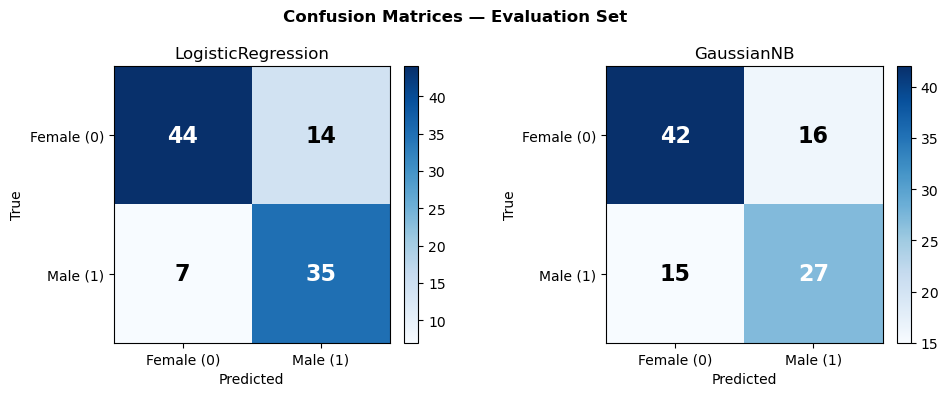

In [38]:
# --- B.7  Confusion matrices ---
plot_confusion_matrices(
    sex_clf_pipelines,
    X_eval_sex,
    y_eval_sex,
    class_names=['Female (0)', 'Male (1)'],
    save_path='../figures/bonusB_confusion_matrices.png',
)

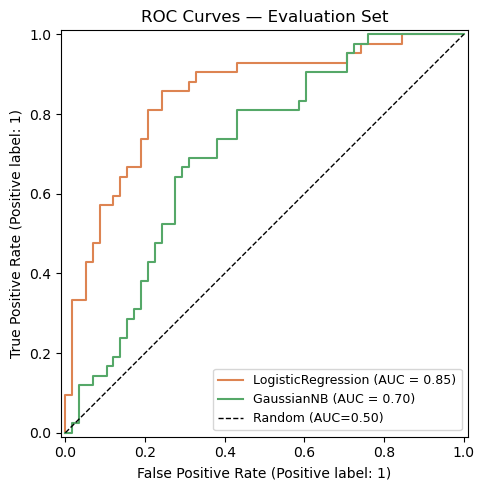

In [39]:
# --- B.8  ROC curves ---
plot_roc_curves(
    sex_clf_pipelines,
    X_eval_sex,
    y_eval_sex,
    save_path='../figures/bonusB_roc_curves.png',
)

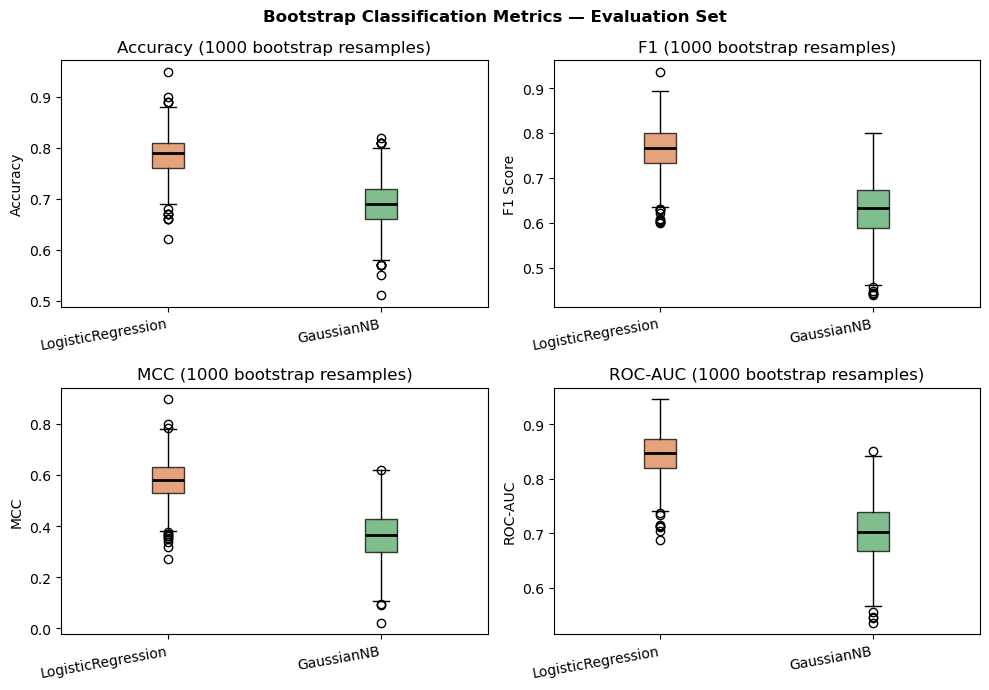

In [40]:
# --- B.9  Bootstrap metric boxplots ---
plot_classification_boxplots(
    sex_clf_raw,
    save_path='../figures/bonusB_bootstrap_boxplots.png',
)

**Results summary (1000 bootstrap resamples, evaluation set, n=100):**

| Model | Accuracy | F1 | MCC | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|
| LogisticRegression | 0.788 [0.710, 0.860] | 0.764 [0.658, 0.854] | 0.579 [0.417, 0.726] | 0.845 [0.764, 0.920] | 0.801 [0.670, 0.908] |
| GaussianNB         | 0.688 [0.600, 0.780] | 0.630 [0.506, 0.750] | 0.362 [0.174, 0.552] | 0.702 [0.595, 0.803] | 0.584 [0.443, 0.744] |